# Harmful Insect Classification Using EfficientNetV2S

## Project Overview

This project presents a deep learning-based image classification system for identifying harmful insect species from images.

The model uses **EfficientNetV2S**, a convolutional neural network architecture available in TensorFlow/Keras, with transfer learning and fine-tuning.

### Dataset

- Number of classes: 50
- Training images: 3,496
- Validation images: 500
- Test images: 999

### Model

- Architecture: EfficientNetV2S
- Framework: TensorFlow / Keras
- Input image size: 384 × 384
- Batch size: 16
- Transfer learning + fine-tuning

### Project Workflow

1. Import required libraries
2. Set random seeds
3. Load and verify the dataset
4. Preprocess and augment images
5. Build the EfficientNetV2S model
6. Train the classification head
7. Fine-tune the model
8. Evaluate performance on the test dataset
9. Generate classification metrics
10. Generate confusion matrix
11. Perform insect image prediction

### Evaluation

The model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

### Technologies Used

- Python
- TensorFlow
- Keras
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn

In [ ]:
# 1. Import Libraries

The required Python libraries are imported for data processing, visualization, deep learning, and model evaluation.
!pip -q install -U tensorflow==2.20.0 scikit-learn seaborn

import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetV2S

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 82.4 MB/s eta 0:00:00
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# 2. Reproducibility

A fixed random seed is used to make the experiment more reproducible.
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seed:", SEED)

Seed: 42


In [ ]:
# 3. Dataset Access

The dataset and project files are stored in Google Drive and accessed through Google Colab.
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# 4. Dataset Configuration

#The dataset contains separate directories for training, validation, and testing.

#The directory structure is:

BASE_DIR = "/content/drive/MyDrive/harmful_insects/dataset"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "valid")
TEST_DIR  = os.path.join(BASE_DIR, "test")

print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)

print("\nTrain exists:", os.path.exists(TRAIN_DIR))
print("Validation exists:", os.path.exists(VAL_DIR))
print("Test exists:", os.path.exists(TEST_DIR))

Train: /content/drive/MyDrive/harmful_insects/dataset/train
Validation: /content/drive/MyDrive/harmful_insects/dataset/valid
Test: /content/drive/MyDrive/harmful_insects/dataset/test

Train exists: True
Validation exists: True
Test exists: True


In [ ]:
# 5. Model and Training Configuration
#The image size, batch size, number of classes, learning rates, number of epochs, and output directories are configured before training.
IMG_SIZE = (384, 384)

BATCH_SIZE = 16

NUM_CLASSES = 50

STAGE1_EPOCHS = 15
STAGE2_EPOCHS = 20

STAGE1_LR = 1e-3
STAGE2_LR = 1e-5

WEIGHT_DECAY = 1e-4

MODEL_DIR = "/content/drive/MyDrive/harmful_insects/models"
RESULT_DIR = "/content/drive/MyDrive/harmful_insects/results"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

print("Configuration ready.")

Configuration ready.


In [ ]:
# 6. Dataset Loading
#The training, validation, and testing datasets are loaded using TensorFlow's image dataset utility.
#Class labels are inferred from the directory names.
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

print("\nNumber of classes:", len(class_names))

for i, name in enumerate(class_names):
    print(i, "->", name)

Found 3496 files belonging to 50 classes.
Found 500 files belonging to 50 classes.
Found 999 files belonging to 50 classes.

Number of classes: 50
0 -> Aedes_aegypti_Yellow_fever_mosquito
1 -> Aedes_albopictus_Asian_tiger_mosquito
2 -> Anoplolepis_gracilipes_Yellow_crazy_ant
3 -> Apis_cerana_Indian_bee
4 -> Apis_dorsata_Giant_honey_bee
5 -> Arctia_decorata_indian_garden_tiger_moth
6 -> Armigeres_subalbatus_Banded_floating_mosquito
7 -> Belostomatidae_sp_giant_water_bug
8 -> Calliphora_spp_Blow_fly
9 -> Camponotus_Carpenter_ant
10 -> Cimex_lectularius_Common_bed_bug
11 -> Coptotermes_spp_Subterranean_termite
12 -> Cordylobia_anthropophaga_Tumbu_fly
13 -> Culex_gelidus_Gelidus_mosquito
14 -> Culex_quinquefasciatus_Southern_house_mosquito
15 -> Dermatobia_hominis_Human_botfly
16 -> Diacamma_rugosum_Bornean_Queenless_ant
17 -> Glossina_Tsete_fly
18 -> Hycleus_biundulatus_Blister_beetle
19 -> Ixodes_spp_Hard_tick
20 -> Latoia_lepida_hairy_itching_caterpillar
21 -> Leiurus_quinquestriatus_de

In [ ]:
# 7. Dataset Verification

#The class ordering of the training, validation, and testing datasets is verified to ensure consistent labels during training and evaluation.
#assert train_ds.class_names == val_ds.class_names
#assert train_ds.class_names == test_ds.class_names

assert len(class_names) == NUM_CLASSES

print("✅ Train / validation / test class ordering is identical.")
print("✅ Number of classes:", len(class_names))

✅ Train / validation / test class ordering is identical.
✅ Number of classes: 50


In [ ]:
# 8. Dataset Performance Optimization

#Prefetching is used to improve the data pipeline performance during model training and evaluation.
#AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Dataset pipeline ready.")

Dataset pipeline ready.


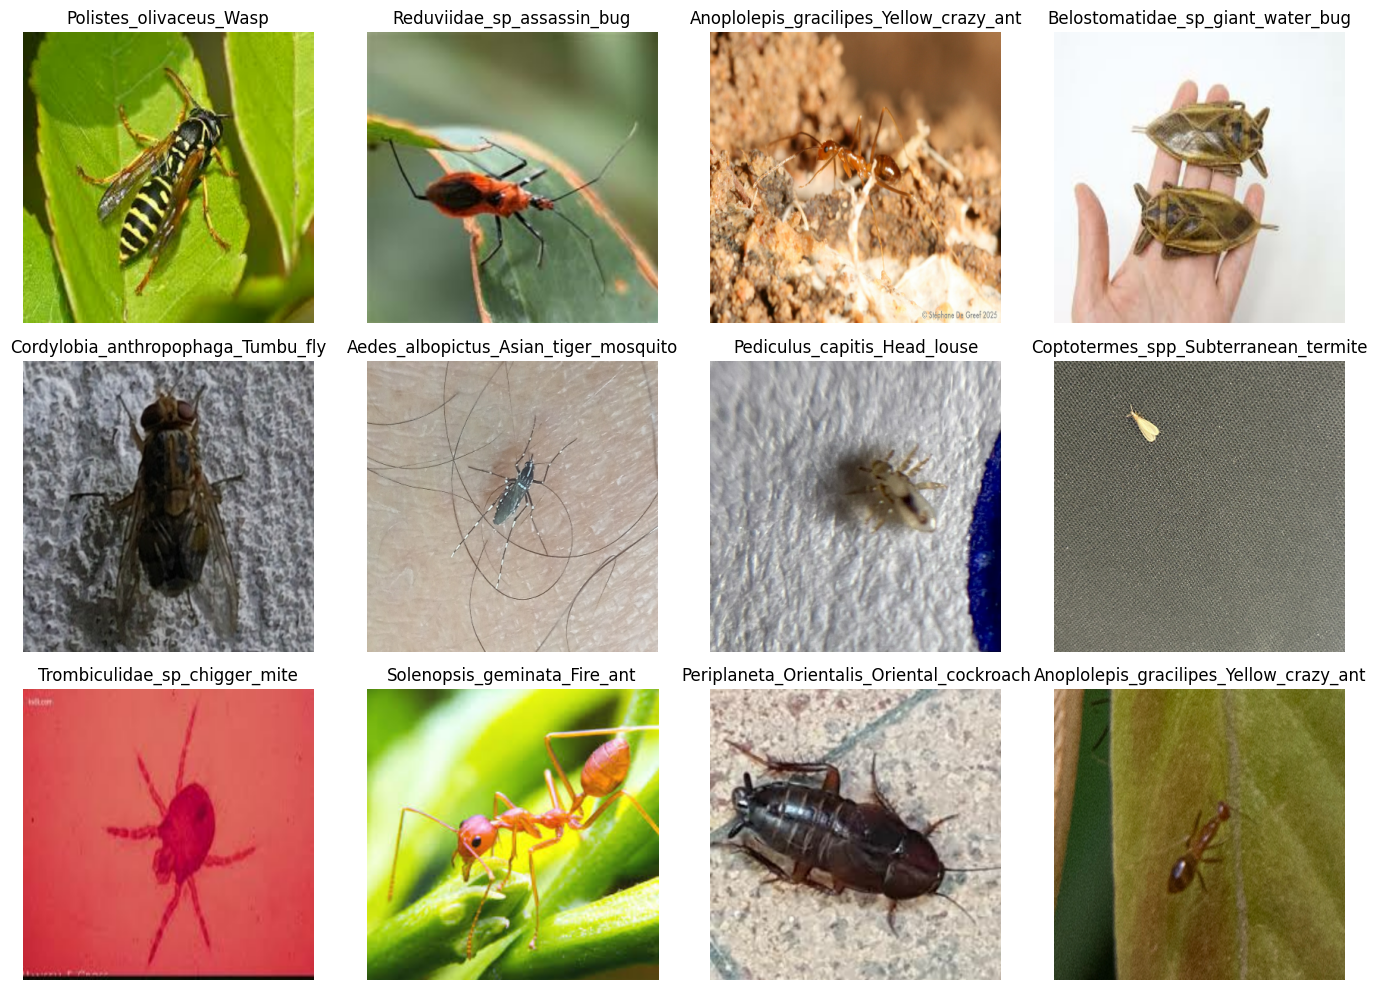

In [ ]:
# 9. Sample Dataset Visualization

#Sample images from the training dataset are displayed along with their corresponding class labels.
plt.figure(figsize=(14, 10))

for images, labels in train_ds.take(1):
    for i in range(min(12, len(images))):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# 10. Data Augmentation

#Data augmentation is applied to increase the diversity of training images and improve the model's ability to generalize to unseen images.

#The augmentation operations include horizontal flipping, rotation, and zooming.
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.10),
        layers.RandomZoom(
            height_factor=(-0.10, 0.15),
            width_factor=(-0.10, 0.15)
        ),
        layers.RandomTranslation(
            height_factor=0.08,
            width_factor=0.08
        ),
        layers.RandomContrast(0.15),
    ],
    name="data_augmentation"
)

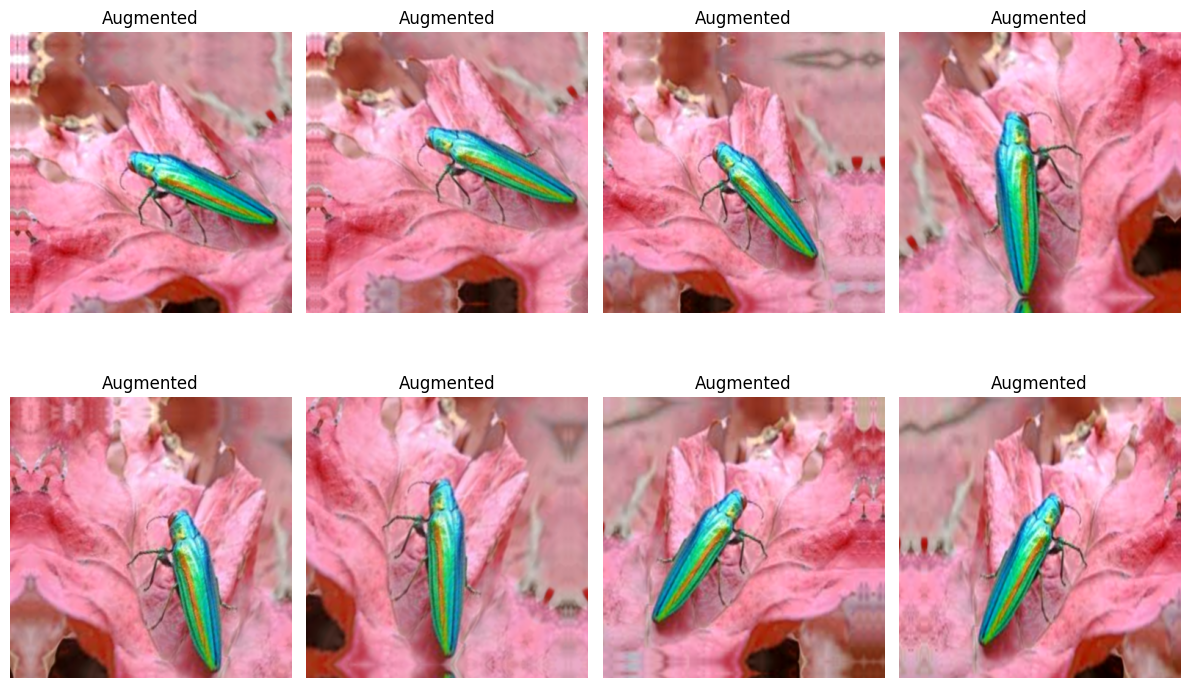

In [ ]:
for images, labels in train_ds.take(1):

    sample_image = images[0:1]

    plt.figure(figsize=(12, 8))

    for i in range(8):

        augmented = data_augmentation(sample_image, training=True)

        ax = plt.subplot(2, 4, i + 1)

        plt.imshow(
            tf.cast(tf.clip_by_value(augmented[0], 0, 255), tf.uint8)
        )

        plt.title("Augmented")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    break

In [ ]:
# 12. Transfer Learning Model
#EfficientNetV2S pretrained on ImageNet is used as the feature extraction backbone.
#Initially, the pretrained backbone is frozen and only the newly added classification layers are trained.
base_model = EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    input_shape=(384, 384, 3)
)

base_model.trainable = False

print("Total layers:", len(base_model.layers))
print("Trainable:", base_model.trainable)

Total layers: 513
Trainable: False


In [ ]:
# 12. Transfer Learning Model

#EfficientNetV2S pretrained on ImageNet is used as the feature extraction backbone.

#Initially, the pretrained backbone is frozen and only the newly added classification layers are trained.
# 13. Model Architecture

#A classification head is added to the pretrained EfficientNetV2S backbone.

#Global average pooling and dense classification layers are used to produce predictions for the 50 insect classes.
inputs = keras.Input(
    shape=(384, 384, 3),
    name="input_image"
)

x = data_augmentation(inputs)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.30)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classifier"
)(x)

model = keras.Model(
    inputs,
    outputs,
    name="Harmful_Insect_EfficientNetV2S"
)

model.summary()

Model: "Harmful_Insect_EfficientNetV2S"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 12, 12, 1280)   │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 50)             │        64,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,400,530 (77.82 MB)

 Trainable params: 66,610 (260.20 KB)

 Non-trainable params: 20,333,920 (77.57 MB)

In [ ]:
# 14. Stage 1 Training

#In the first training stage, the pretrained EfficientNetV2S backbone remains frozen.

#The newly added classification layers are trained using the training dataset and evaluated using the validation dataset.
optimizer_stage1 = keras.optimizers.AdamW(
    learning_rate=STAGE1_LR,
    weight_decay=WEIGHT_DECAY
)

model.compile(
    optimizer=optimizer_stage1,
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Stage 1 compiled.")

Stage 1 compiled.


In [ ]:
best_model_path = os.path.join(
    MODEL_DIR,
    "best_efficientnetv2s.keras"
)

callbacks = [

    keras.callbacks.ModelCheckpoint(
        best_model_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [ ]:
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE1_EPOCHS,
    callbacks=callbacks
)

Epoch 1/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.2867 - loss: 2.9064
Epoch 1: val_accuracy improved from None to 0.65200, saving model to /content/drive/MyDrive/harmful_insects/models/best_efficientnetv2s.keras

Epoch 1: finished saving model to /content/drive/MyDrive/harmful_insects/models/best_efficientnetv2s.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 95s 313ms/step - accuracy: 0.4316 - loss: 2.1043 - val_accuracy: 0.6520 - val_loss: 1.2744 - learning_rate: 0.0010
Epoch 2/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.6404 - loss: 1.1428
Epoch 2: val_accuracy improved from 0.65200 to 0.70600, saving model to /content/drive/MyDrive/harmful_insects/models/best_efficientnetv2s.keras

Epoch 2: finished saving model to /content/drive/MyDrive/harmful_insects/models/best_efficientnetv2s.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 65s 295ms/step - accuracy: 0.6530 - loss: 1.1162 - val_accuracy: 0.7060 - val_loss: 0.8585 - learning_rate: 0.0010
Epoch 3/15
219/219 ━━━━━━━━━━━━━━

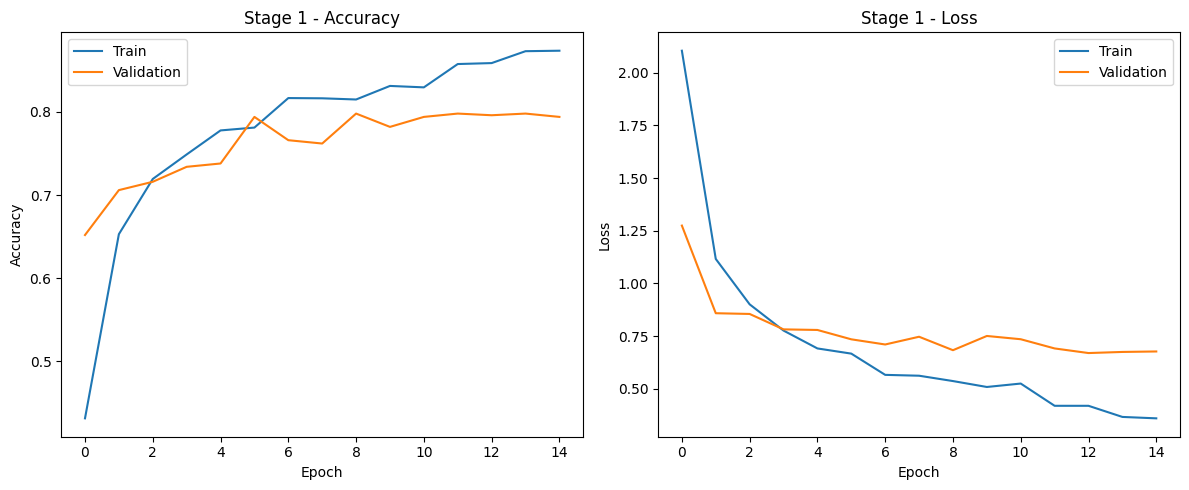

In [ ]:
# 15. Training Performance
#Training and validation accuracy and loss are visualized to observe the learning behavior of the model.
def plot_history(history, title):

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)

    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Validation")

    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)

    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Validation")

    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_history(
    history_stage1,
    "Stage 1"
)

In [ ]:
# 16. Fine-Tuning

#After the initial training stage, selected layers of the pretrained EfficientNetV2S backbone are unfrozen.

#Fine-tuning allows the model to adapt pretrained features to the harmful insect classification dataset.

#Batch normalization layers are kept frozen to improve training stability.
base_model.trainable = True

total_layers = len(base_model.layers)

fine_tune_from = int(total_layers * 0.70)

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_from:]:
    layer.trainable = True

trainable_layers = sum(
    1 for layer in base_model.layers
    if layer.trainable
)

print("Total backbone layers:", total_layers)
print("Fine-tuning from:", fine_tune_from)
print("Trainable backbone layers:", trainable_layers)

Total backbone layers: 513
Fine-tuning from: 359
Trainable backbone layers: 154


In [ ]:
for layer in base_model.layers:

    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

In [ ]:
print(
    "Trainable layers:",
    sum(1 for layer in base_model.layers if layer.trainable)
)

Trainable layers: 123


In [ ]:
optimizer_stage2 = keras.optimizers.AdamW(
    learning_rate=STAGE2_LR,
    weight_decay=WEIGHT_DECAY
)

model.compile(
    optimizer=optimizer_stage2,
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Stage 2 compiled.")

Stage 2 compiled.


In [ ]:
fine_tune_callbacks = [

    keras.callbacks.ModelCheckpoint(
        best_model_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [ ]:
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE2_EPOCHS,
    callbacks=fine_tune_callbacks
)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.8719 - loss: 0.3836
Epoch 1: val_accuracy improved from None to 0.81000, saving model to /content/drive/MyDrive/harmful_insects/models/best_efficientnetv2s.keras

Epoch 1: finished saving model to /content/drive/MyDrive/harmful_insects/models/best_efficientnetv2s.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 122s 407ms/step - accuracy: 0.8887 - loss: 0.3389 - val_accuracy: 0.8100 - val_loss: 0.6579 - learning_rate: 1.0000e-05
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.8994 - loss: 0.3124
Epoch 2: val_accuracy improved from 0.81000 to 0.81600, saving model to /content/drive/MyDrive/harmful_insects/models/best_efficientnetv2s.keras

Epoch 2: finished saving model to /content/drive/MyDrive/harmful_insects/models/best_efficientnetv2s.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 84s 385ms/step - accuracy: 0.8965 - loss: 0.3135 - val_accuracy: 0.8160 - val_loss: 0.6465 - learning_rate: 1.0000e-05
Epoch 3/20
219/219 ━━━━━

In [ ]:
# 17. Load Best Model

#The model checkpoint with the best validation performance is loaded for final evaluation.
model = keras.models.load_model(
    best_model_path
)

print("✅ Best model loaded:")
print(best_model_path)

✅ Best model loaded:
/content/drive/MyDrive/harmful_insects/models/best_efficientnetv2s.keras


In [ ]:
# 18. Test Set Evaluation

#The trained model is evaluated on the independent test dataset.

#Test accuracy and test loss are calculated to measure the final classification performance.
test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("\n==============================")
print("FINAL TEST RESULTS")
print("==============================")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 392s 6s/step - accuracy: 0.7728 - loss: 0.8842

FINAL TEST RESULTS
Test Loss     : 0.8842
Test Accuracy : 77.28%


In [ ]:
# 19. Generate Predictions

#Predictions are generated for the complete test dataset.

#The predicted labels and true labels are stored for further evaluation.
y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))
    y_prob.extend(predictions)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("Samples evaluated:", len(y_true))

Samples evaluated: 999


In [ ]:
# 20. Classification Report

#Precision, recall, F1-score, and support are calculated for each insect class.
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

display(report_df)

,precision,recall,f1-score,support
Aedes_aegypti_Yellow_fever_mosquito,0.545455,0.300000,0.387097,20.000000
Aedes_albopictus_Asian_tiger_mosquito,0.562500,0.900000,0.692308,20.000000
Anoplolepis_gracilipes_Yellow_crazy_ant,0.625000,0.750000,0.681818,20.000000
Apis_cerana_Indian_bee,0.636364,0.700000,0.666667,20.000000
Apis_dorsata_Giant_honey_bee,0.368421,0.350000,0.358974,20.000000
Arctia_decorata_indian_garden_tiger_moth,1.000000,1.000000,1.000000,20.000000
Armigeres_subalbatus_Banded_floating_mosquito,0.833333,0.750000,0.789474,20.000000
Belostomatidae_sp_giant_water_bug,1.000000,0.950000,0.974359,20.000000
Calliphora_spp_Blow_fly,0.823529,0.700000,0.756757,20.000000
Camponotus_Carpenter_ant,0.937500,0.750000,0.833333,20.000000


In [ ]:
# 21. Save Evaluation Results

#The classification report is saved as a CSV file for further analysis and documentation.
report_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "classification_report.csv"
    )
)

print("Saved classification report.")

Saved classification report.


In [ ]:
# 22. Overall Performance Metrics

#Overall accuracy, macro-averaged precision, recall, and F1-score are calculated to summarize the model's classification performance.
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="macro"
)

weighted_precision, weighted_recall, weighted_f1, _ = \
    precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted"
    )

print(f"Accuracy          : {accuracy * 100:.2f}%")
print(f"Macro Precision   : {precision:.4f}")
print(f"Macro Recall      : {recall:.4f}")
print(f"Macro F1          : {f1:.4f}")
print(f"Weighted F1       : {weighted_f1:.4f}")

Accuracy          : 77.28%
Macro Precision   : 0.7864
Macro Recall      : 0.7729
Macro F1          : 0.7689
Weighted F1       : 0.7688


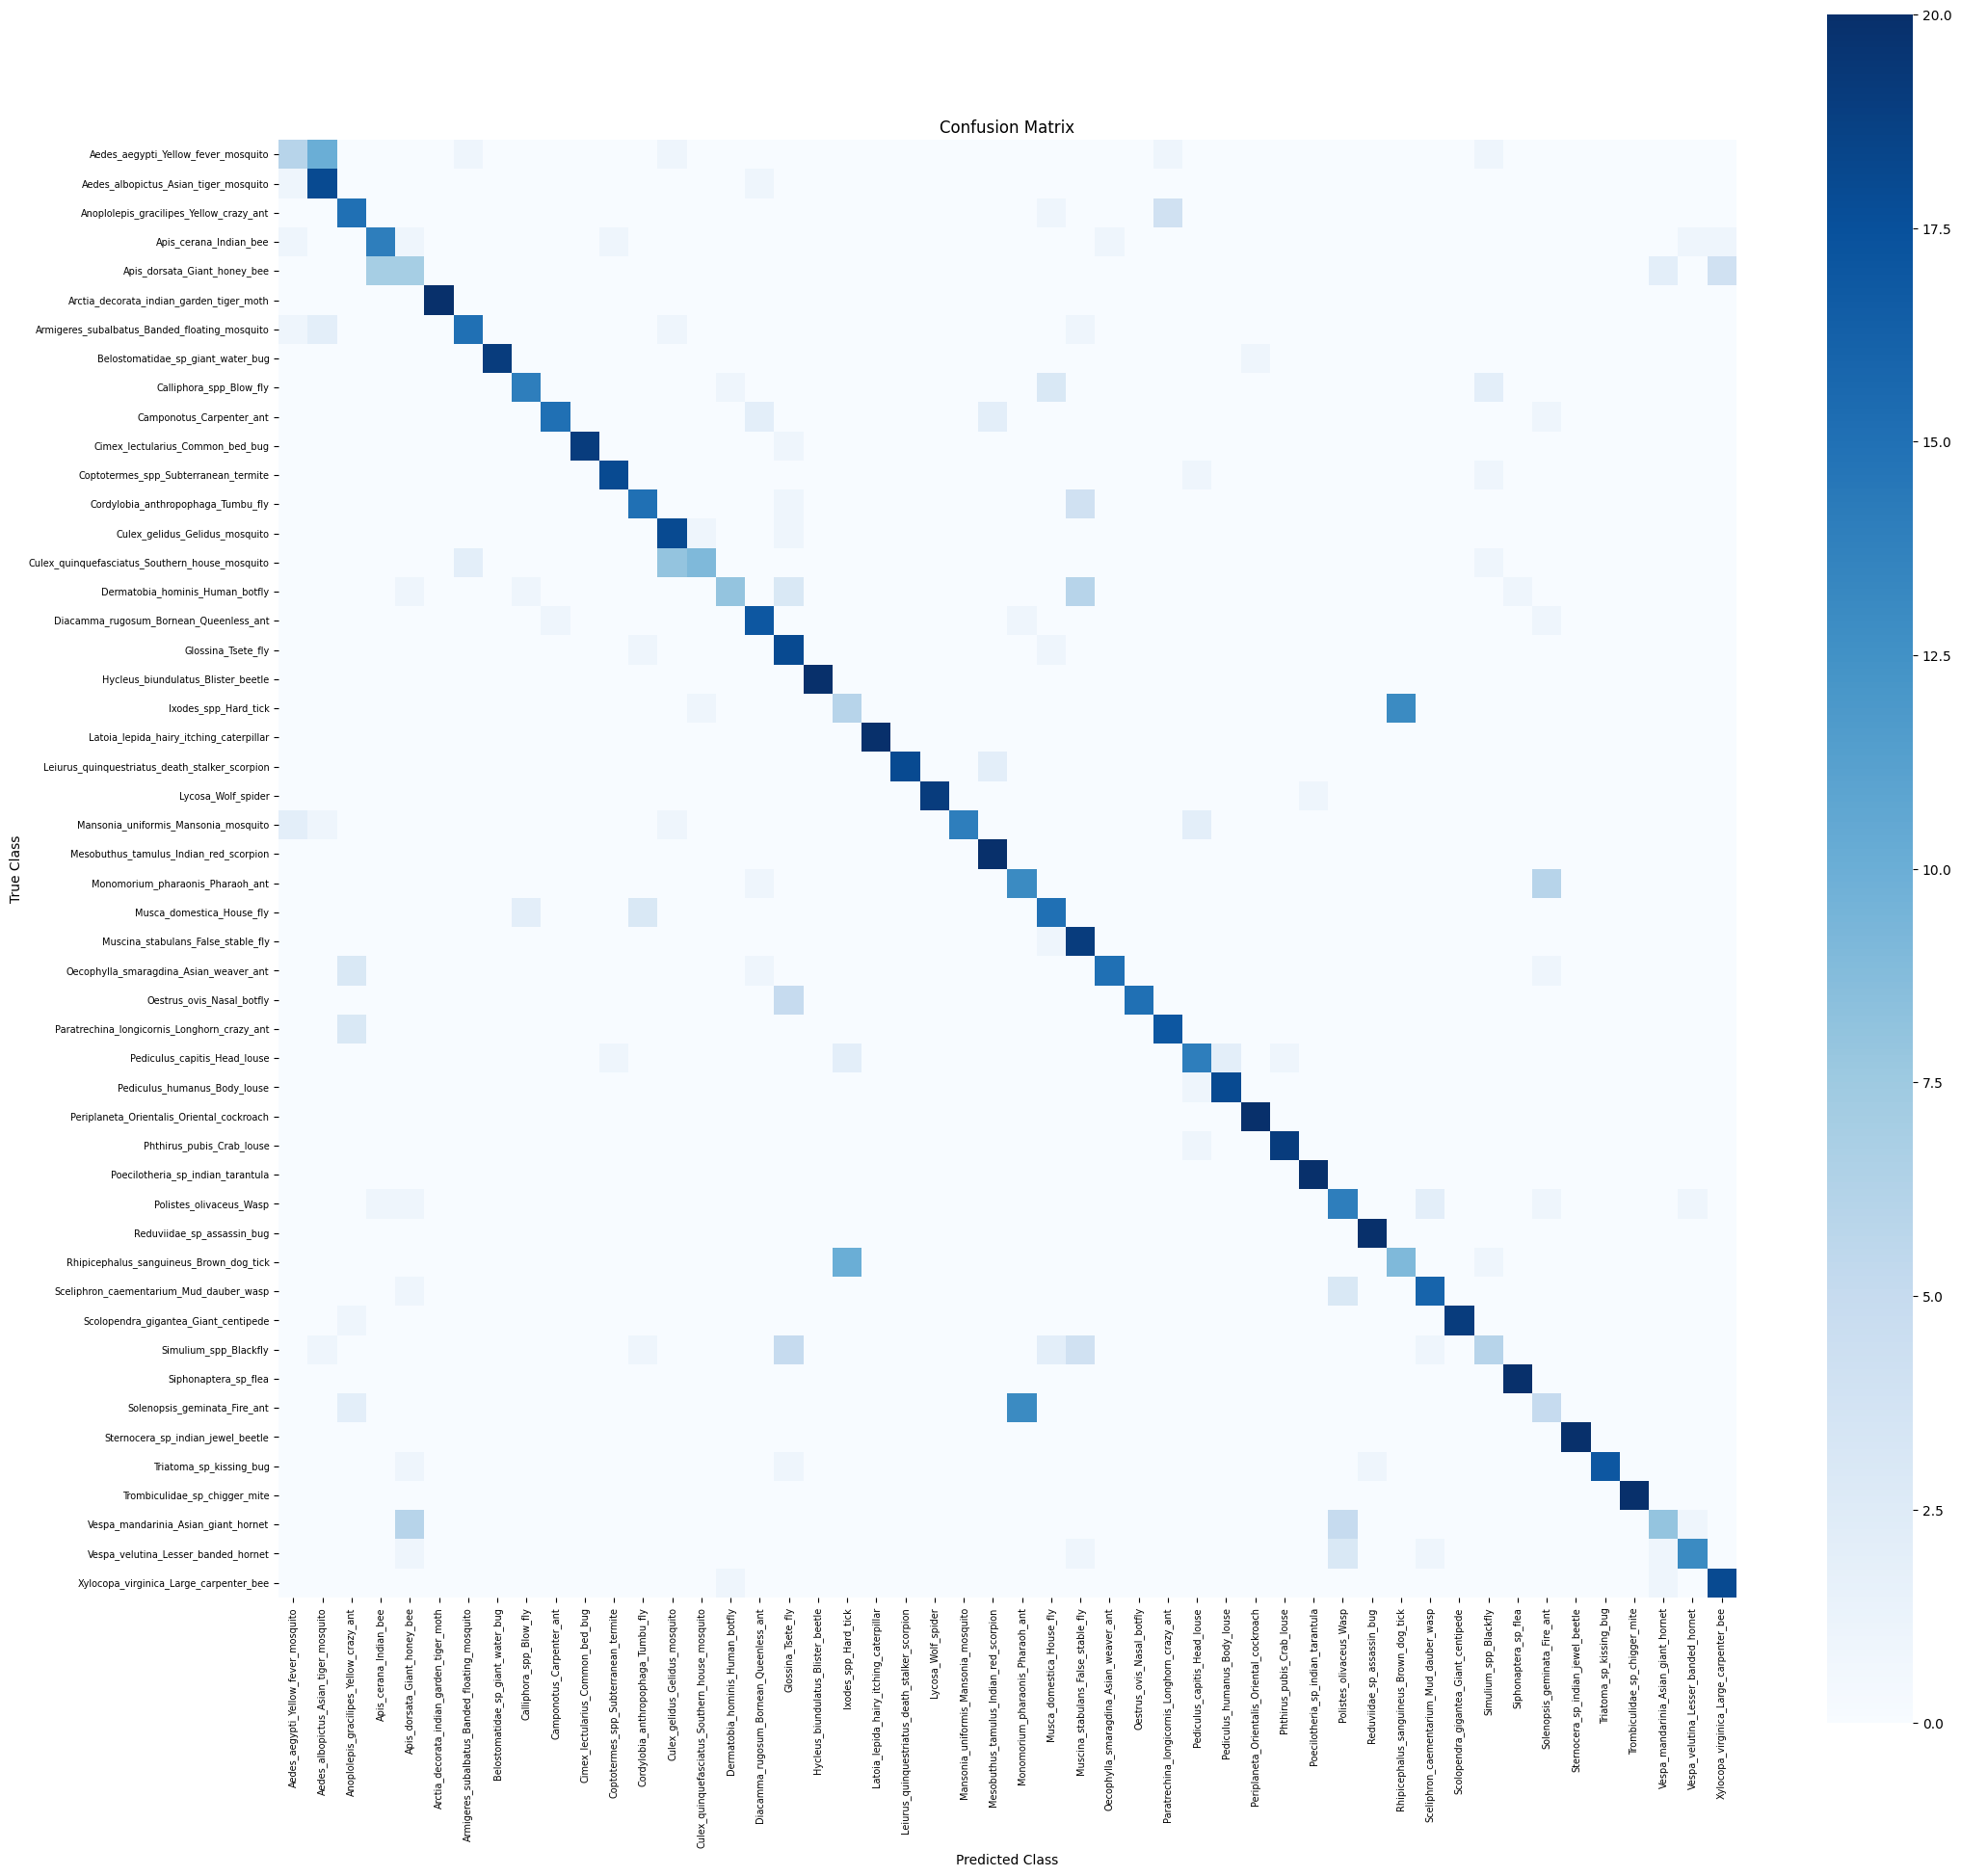

In [ ]:
# 23. Confusion Matrix

#A confusion matrix is generated to visualize the classification performance across the 50 insect classes.

#It helps identify classes that are frequently confused with one another.
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(22, 20))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    square=True,
    cbar=True
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")

plt.xticks(
    rotation=90,
    fontsize=7
)

plt.yticks(
    rotation=0,
    fontsize=7
)

plt.tight_layout()

cm_path = os.path.join(
    RESULT_DIR,
    "confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# 24. Per-Class Accuracy Analysis

#The classification accuracy of individual insect classes is calculated.

#The classes with relatively higher and lower classification accuracy are visualized for further analysis.
per_class_accuracy = {}

for i, class_name in enumerate(class_names):

    mask = y_true == i

    if np.sum(mask) > 0:

        class_acc = np.mean(
            y_pred[mask] == i
        )

        per_class_accuracy[class_name] = class_acc

per_class_df = (
    pd.DataFrame(
        list(per_class_accuracy.items()),
        columns=["Class", "Accuracy"]
    )
    .sort_values(
        "Accuracy",
        ascending=False
    )
)

display(per_class_df)

,Class,Accuracy
5,Arctia_decorata_indian_garden_tiger_moth,1.000000
18,Hycleus_biundulatus_Blister_beetle,1.000000
35,Poecilotheria_sp_indian_tarantula,1.000000
37,Reduviidae_sp_assassin_bug,1.000000
44,Sternocera_sp_indian_jewel_beetle,1.000000
42,Siphonaptera_sp_flea,1.000000
33,Periplaneta_Orientalis_Oriental_cockroach,1.000000
24,Mesobuthus_tamulus_Indian_red_scorpion,1.000000
20,Latoia_lepida_hairy_itching_caterpillar,1.000000
46,Trombiculidae_sp_chigger_mite,1.000000


In [ ]:
per_class_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "per_class_accuracy.csv"
    ),
    index=False
)

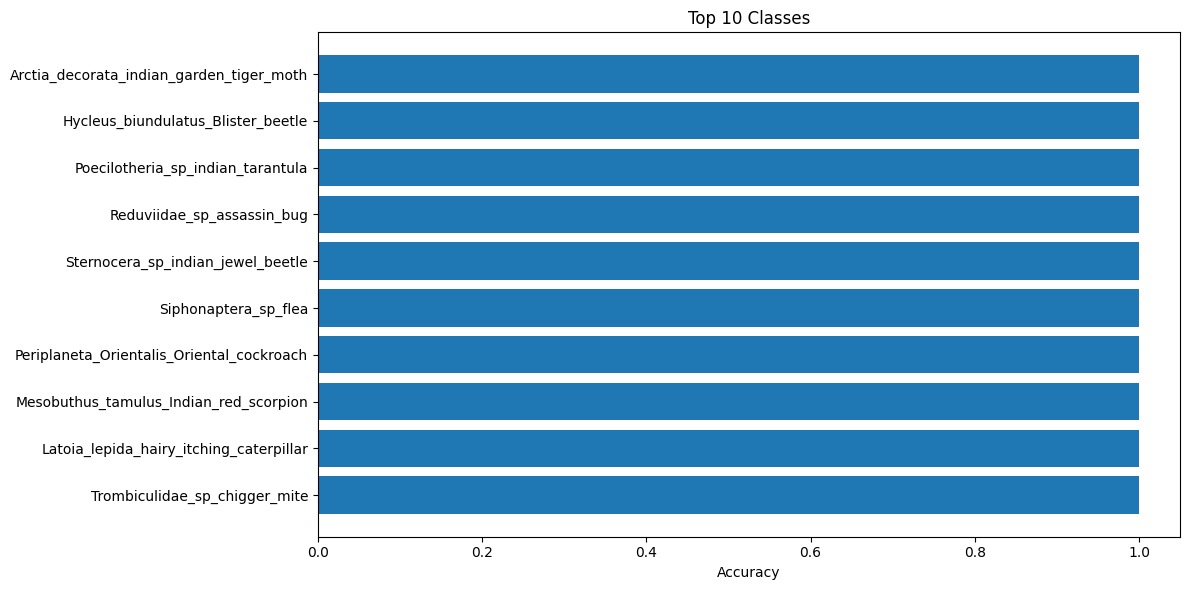

In [ ]:
best_classes = per_class_df.head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    best_classes["Class"],
    best_classes["Accuracy"]
)

plt.xlabel("Accuracy")
plt.title("Top 10 Classes")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

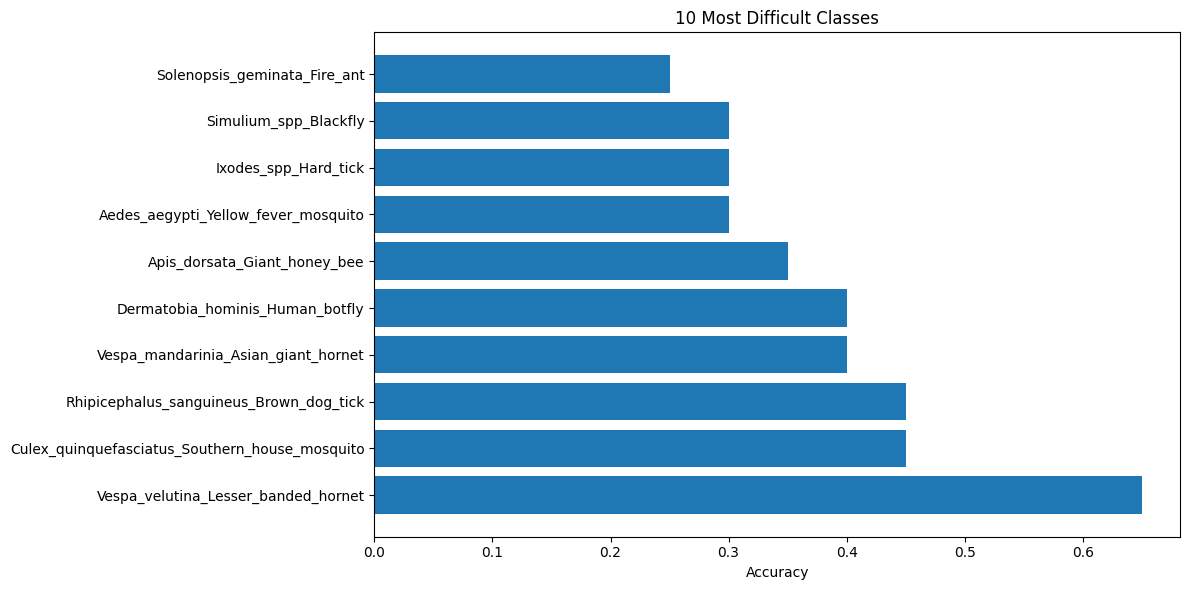

In [ ]:
worst_classes = per_class_df.tail(10)

plt.figure(figsize=(12, 6))

plt.barh(
    worst_classes["Class"],
    worst_classes["Accuracy"]
)

plt.xlabel("Accuracy")
plt.title("10 Most Difficult Classes")

plt.tight_layout()

plt.show()

In [ ]:
# 25. Save Trained Model

#The class names and trained model are saved for future inference and deployment.
class_names_path = os.path.join(
    MODEL_DIR,
    "class_names.json"
)

with open(class_names_path, "w") as f:

    json.dump(
        class_names,
        f,
        indent=4
    )

print("Saved:", class_names_path)

Saved: /content/drive/MyDrive/harmful_insects/models/class_names.json


In [ ]:
final_model_path = os.path.join(
    MODEL_DIR,
    "harmful_insect_classifier.keras"
)

model.save(
    final_model_path
)

print("Model saved:")
print(final_model_path)

Model saved:
/content/drive/MyDrive/harmful_insects/models/harmful_insect_classifier.keras


In [ ]:
# 26. Inference on a New Image

#The trained model is used to predict the insect class of a previously unseen image.
def predict_image(image_path):

    image = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    image_array = tf.keras.utils.img_to_array(
        image
    )

    image_array = tf.expand_dims(
        image_array,
        axis=0
    )

    probabilities = model.predict(
        image_array,
        verbose=0
    )[0]

    top_indices = np.argsort(
        probabilities
    )[-5:][::-1]

    print("\nTop-5 Predictions")
    print("====================")

    for idx in top_indices:

        print(
            f"{class_names[idx]:50s} "
            f"{probabilities[idx] * 100:.2f}%"
        )

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(
        f"Prediction: {class_names[top_indices[0]]}"
    )
    plt.axis("off")
    plt.show()


Top-5 Predictions
Apis_cerana_Indian_bee                             63.34%
Xylocopa_virginica_Large_carpenter_bee             25.27%
Apis_dorsata_Giant_honey_bee                       5.64%
Oestrus_ovis_Nasal_botfly                          4.87%
Musca_domestica_House_fly                          0.35%


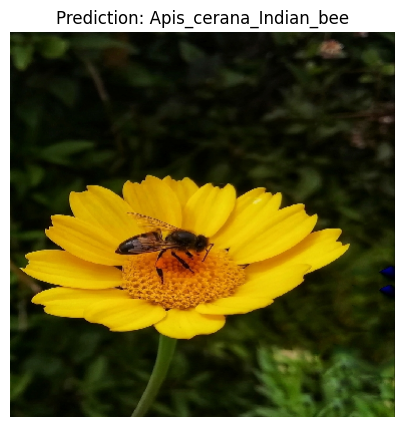

In [ ]:
predict_image(
    "/content/drive/MyDrive/harmful_insects/dataset/test/Apis_cerana_Indian_bee/test2.jpg"
)

In [ ]:
# 27. Dataset Quality Checks

#The test dataset is checked for image counts, file extensions, and unsupported image files.

#These checks help ensure that the evaluation dataset is valid and consistent.
import os

def count_images(folder):
    extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

    total = 0
    class_counts = {}

    for class_name in sorted(os.listdir(folder)):
        class_path = os.path.join(folder, class_name)

        if not os.path.isdir(class_path):
            continue

        count = 0

        for file in os.listdir(class_path):
            if file.lower().endswith(extensions):
                count += 1

        class_counts[class_name] = count
        total += count

    return total, class_counts


train_total, train_counts = count_images(TRAIN_DIR)
val_total, val_counts = count_images(VAL_DIR)
test_total, test_counts = count_images(TEST_DIR)

print("TRAIN :", train_total)
print("VAL   :", val_total)
print("TEST  :", test_total)

print("\nClasses with TEST count != 20:")

for cls, count in test_counts.items():
    if count != 20:
        print(cls, "->", count)

TRAIN : 3500
VAL   : 500
TEST  : 1000

Classes with TEST count != 20:


In [ ]:
from collections import Counter
import os

extensions = Counter()

for class_name in sorted(os.listdir(TEST_DIR)):
    class_path = os.path.join(TEST_DIR, class_name)

    if not os.path.isdir(class_path):
        continue

    for file in os.listdir(class_path):
        ext = os.path.splitext(file)[1].lower()
        extensions[ext] += 1

print("TEST FILE EXTENSIONS:")
for ext, count in sorted(extensions.items()):
    print(f"{ext:10s} : {count}")

TEST FILE EXTENSIONS:
.jpeg      : 575
.jpg       : 423
.png       : 1
.webp      : 1


In [ ]:
for class_name in sorted(os.listdir(TEST_DIR)):

    class_path = os.path.join(TEST_DIR, class_name)

    if not os.path.isdir(class_path):
        continue

    for file in os.listdir(class_path):

        ext = os.path.splitext(file)[1].lower()

        if ext not in [".jpg", ".jpeg", ".png", ".bmp", ".gif"]:
            print("Unsupported file:")
            print("Class :", class_name)
            print("File  :", file)
            print("Path  :", os.path.join(class_path, file))

Unsupported file:
Class : Pediculus_humanus_Body_louse
File  : i8.webp
Path  : /content/drive/MyDrive/harmful_insects/dataset/test/Pediculus_humanus_Body_louse/i8.webp


In [ ]:
from PIL import Image
import os

bad_path = r"/content/drive/MyDrive/harmful_insects/dataset/test/Pediculus_humanus_Body_louse/i8.webp"

img = Image.open(bad_path).convert("RGB")

new_path = os.path.splitext(bad_path)[0] + ".jpg"

img.save(new_path, "JPEG", quality=95)

print("Created:")
print(new_path)

Created:
/content/drive/MyDrive/harmful_insects/dataset/test/Pediculus_humanus_Body_louse/i8.jpg


In [ ]:
# Remove the identified unsupported/corrupted image after verification.
os.remove(bad_path)

print("Original unsupported file removed.")

Original unsupported file removed.


In [ ]:
test_total, test_counts = count_images(TEST_DIR)

print("TEST :", test_total)

print("\nClasses with TEST count != 20:")

for cls, count in test_counts.items():
    if count != 20:
        print(cls, "->", count)

TEST : 1000

Classes with TEST count != 20:


In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Number of test classes:", len(test_ds.class_names))

test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

test_count = 0

for images, labels in test_ds:
    test_count += images.shape[0]

print("Actual test images:", test_count)

Found 1000 files belonging to 50 classes.
Number of test classes: 50
Actual test images: 1000


In [ ]:
model = keras.models.load_model(
    best_model_path
)

test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("\n==============================")
print("CORRECTED TEST RESULTS")
print("==============================")
print(f"Test images  : {test_count}")
print(f"Test loss    : {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 225ms/step - accuracy: 0.7730 - loss: 0.8822

CORRECTED TEST RESULTS
Test images  : 1000
Test loss    : 0.8822
Test accuracy: 77.30%


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.models import load_model

# ==============================
# PATHS
# ==============================

MODEL_DIR = "/content/drive/MyDrive/harmful_insects/models"
TEST_DIR = "/content/drive/MyDrive/harmful_insects/dataset/test"

model_paths = {
    "best_efficientnetv2s": os.path.join(
        MODEL_DIR, "best_efficientnetv2s.keras"
    ),
    "harmful_insect_classifier": os.path.join(
        MODEL_DIR, "harmful_insect_classifier.keras"
    )
}

# ==============================
# TEST DATA
# ==============================

IMG_SIZE = (384, 384)
BATCH_SIZE = 32

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = test_ds.class_names
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Number of test images:", len(test_ds.file_paths))

# ==============================
# EVALUATE MODELS
# ==============================

for model_name, model_path in model_paths.items():

    print("\n" + "=" * 60)
    print("MODEL:", model_name)
    print("=" * 60)

    print("Loading:", model_path)

    model = load_model(model_path)

    print("Model loaded successfully.")

    results = model.evaluate(
        test_ds,
        verbose=1,
        return_dict=True
    )

    print("\nRESULTS")

    for metric, value in results.items():
        print(f"{metric}: {value:.4f}")

Found 1000 files belonging to 50 classes.
Number of classes: 50
Number of test images: 1000

MODEL: best_efficientnetv2s
Loading: /content/drive/MyDrive/harmful_insects/models/best_efficientnetv2s.keras
Model loaded successfully.
32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 423ms/step - accuracy: 0.7730 - loss: 0.8822

RESULTS
accuracy: 0.7730
loss: 0.8822

MODEL: harmful_insect_classifier
Loading: /content/drive/MyDrive/harmful_insects/models/harmful_insect_classifier.keras
Model loaded successfully.
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 415ms/step - accuracy: 0.7730 - loss: 0.8822

RESULTS
accuracy: 0.7730
loss: 0.8822


# 28. Conclusion

A deep learning-based harmful insect classification system was developed using transfer learning with EfficientNetV2S.

The dataset contains 50 insect classes and is divided into training, validation, and testing subsets.

Data augmentation was applied to improve generalization, followed by transfer learning and fine-tuning.

The final model was evaluated using accuracy, precision, recall, F1-score, confusion matrix, and per-class accuracy.

The trained model can also be used to classify previously unseen insect images.

## Future Scope

- Increase the size and diversity of the dataset.
- Improve classification performance for visually similar insect species.
- Deploy the trained model as a web or mobile application.
- Optimize the model for real-time insect identification.